# MSDL-JCI — Thesis-Aligned Multi-Source Deep Learning for JCI Direction Prediction

Implements the hybrid architecture from the thesis defense: LSTM (technical) + MLP Encoder (macro) + 
Frozen IndoBERT (news) + Adaptive MLP Fusion (Soft Gating Network). 
Walk-forward validation with AUC/F1/Sharpe metrics. Leak-free pipeline preserved.
Leak-free order: align → train-only scaling → window (lookback 28) → t+5 labels.


In [1]:
%matplotlib inline
import os
import sqlite3
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler

# Deep learning setup (thesis Table 5)
try:
    import torch
    from torch import nn
    from transformers import AutoModel, AutoTokenizer

    _HAS_TORCH = True
except ImportError:
    _HAS_TORCH = False
    torch = None
    nn = None
    AutoModel = None
    AutoTokenizer = None

NB_ROOT = Path.cwd().resolve()
while not (NB_ROOT / "pyproject.toml").exists() and NB_ROOT != NB_ROOT.parent:
    NB_ROOT = NB_ROOT.parent
load_dotenv(NB_ROOT / ".env")

_raw_db = Path(os.getenv("DATABASE_PATH", "database/main_database.db"))
DB_PATH = _raw_db if _raw_db.is_absolute() else NB_ROOT / _raw_db


@dataclass(frozen=True)
class Config:
    look_back: int = int(os.getenv("ML_LOOK_BACK", "28"))
    horizon: int = int(os.getenv("ML_PREDICTION_HORIZON", "5"))
    hidden_layers: tuple = eval(os.getenv("ML_HIDDEN_LAYERS", "(32, 16)"))
    projection_dim: int = int(os.getenv("ML_PROJECTION_DIM", "64"))
    lstm_dim: int = int(os.getenv("ML_LSTM_DIM", "64"))
    lstm_lookback: int = int(os.getenv("ML_LSTM_LOOKBACK", "28"))
    fusion_input_dim: int = int(os.getenv("ML_FUSION_INPUT_DIM", "144"))
    fusion_output_dim: int = int(os.getenv("ML_FUSION_OUTPUT_DIM", "3"))
    seed: int = int(os.getenv("ML_RANDOM_STATE", "42"))
    tech_cols: list = field(
        default_factory=lambda: [
            "Close",
            "Volume",
            "RSI_14",
            "MACD",
            "MACD_Signal",
            "ATR_14",
            "SMA_20",
        ]
    )
    macro_cols: list = field(default_factory=lambda: ["bi_rate", "inflation_rate", "usd_idr"])


CFG = Config()

/home/jwjooth/project/msdl-jci/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Config & hyperparameters

One `Config`, env-overridable (see `.env.example`). Table 5 defaults baked in.

| Parameter | Default | Description |
|---|---|---|
| `look_back` | 28 | Technical lookback window (LSTM) |
| `horizon` | 5 | t+5 directional label |
| `seed` | 42 | RNG seed |
| `hidden_layers` | (32, 16) | MLP Encoder hidden units |
| `projection_dim` | 64 | News embedding projection (768 → 64) |
| `lstm_dim` | 64 | LSTM hidden size |
| `lstm_lookback` | 28 | Technical sequence length |
| `fusion_input_dim` | 144 | Concatenated features (64 + 16 + 64) |
| `fusion_output_dim` | 3 | Gating weights (α, β, γ) via Softmax |


np.random.seed(CFG.seed)
df = align(*load_frames())
lb = CFG.look_back
n_win = len(df) - lb + 1
train_end_df = int(n_win * 0.70) + lb - 1  # window space → df space
t, feat_scaler = make_tensors(df, train_end_df)
print(f"rows: {len(df)} | samples: {len(t.y)} | X_tech: {t.X_tech.shape}")
print(f"range: {t.dates[0]} → {t.dates[-1]} | pos_rate: {t.y.mean():.3f}")

# Thesis model: instantiate and run demo evaluation
if _HAS_TORCH:
    model = StockModel(CFG)
    model.eval()
    metrics = evaluate_model(model, df, CFG)
    print(f"Model eval: prob={metrics['prob']:.4f}, auc={metrics['auc']}, acc={metrics['acc']}, f1={metrics['f1']}")
    
    # Walk-forward evaluation (thesis methodology)
    wf_metrics = walk_forward_evaluate(model, df, CFG, n_splits=5)
    print(f"Walk-forward: auc={wf_metrics['auc']:.4f}, acc={wf_metrics['acc']:.4f}, f1={wf_metrics['f1']:.4f}")
else:
    print("Torch not available — skipping model evaluation")
    model = None
    metrics = {}
    wf_metrics = {}


In [2]:
ENTITY_TABLES = {
    "jci_historical": ("Date", "Close", "High", "Low", "Open", "Volume"),
    "bi_rate": ("Period", "BI-7Day-RR"),
    "inflation_data": ("Periode", "Data Inflasi"),
    "kurs_usdidr": ("Date", "Close", "High", "Low", "Open"),
    "cnbc_ihsg_articles": ("title", "url", "publish_date", "content", "scraped_at"),
    "detik_ihsg_articles": ("title", "url", "snippet", "published", "scraped_at"),
    "kontan_ihsg_articles": ("title", "url", "snippet", "published", "category", "scraped_at"),
}


def read_table(name):
    # ponytail: stdlib sqlite3, not SQLAlchemy — single-file DB, no server, no ORM gain.
    # Upgrade path: sqlalchemy.create_engine if this ever needs pools/concurrency.
    with sqlite3.connect(DB_PATH) as con:
        df = pd.read_sql_query(f"SELECT * FROM [{name}]", con)
    missing = [c for c in ENTITY_TABLES[name] if c not in df.columns]
    if missing:
        raise ValueError(f"Table [{name}] missing columns {missing}: {list(df.columns)}")
    return df


USE_DB = DB_PATH.exists()
print("source:", "SQLite" if USE_DB else "synthetic fallback", "→", DB_PATH)

source: SQLite → /home/jwjooth/project/msdl-jci/database/main_database.db


## Utilities

Causal indicators (past-only), Indonesian dates, ffill-only macro alignment,
t+5 labels, train-only scaling + windowed tensors.

In [3]:
def parse_id_date(s, day_first=True):
    """Parse Indonesian-formatted dates using pandas mixed-format parser."""
    return pd.to_datetime(
        s.astype(str).str.lower(), format="mixed", errors="coerce", dayfirst=day_first
    )


def add_indicators(df):
    c = df["Close"].astype(float)
    h, l = df["High"].astype(float), df["Low"].astype(float)
    d = c.diff()
    ag = d.clip(lower=0).ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
    al = (-d.clip(upper=0)).ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
    df["RSI_14"] = 100 - 100 / (1 + ag / (al + 1e-9))
    df["MACD"] = c.ewm(span=12, adjust=False).mean() - c.ewm(span=26, adjust=False).mean()
    df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
    pc = c.shift(1)
    tr = pd.concat([h - l, (h - pc).abs(), (l - pc).abs()], axis=1).max(axis=1)
    df["ATR_14"] = tr.ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
    df["SMA_20"] = c.rolling(20).mean()
    return df


def load_frames():
    """(jci, bi, inf, kur) raw frames — real DB when present, else synthetic."""
    if USE_DB:
        return (
            read_table("jci_historical"),
            read_table("bi_rate"),
            read_table("inflation_data"),
            read_table("kurs_usdidr"),
        )
    rng = np.random.default_rng(CFG.seed)
    days = pd.date_range("2023-01-02", periods=500, freq="B")
    close = 6900 + np.cumsum(rng.normal(0, 18, len(days)))
    jci = pd.DataFrame(
        {
            "Date": days,
            "Open": close - 5,
            "High": close + 10,
            "Low": close - 10,
            "Close": close,
            "Volume": 5e7,
        }
    )
    id_months = [
        "Januari",
        "Februari",
        "Maret",
        "April",
        "Mei",
        "Juni",
        "Juli",
        "Agustus",
        "September",
        "Oktober",
        "November",
        "Desember",
    ]
    months = pd.date_range("2023-01-01", periods=17, freq="MS")
    bi = pd.DataFrame(
        {
            "Period": [f"15 {id_months[m.month - 1]} {m.year}" for m in months],
            "BI-7Day-RR": [f"{5.5 + 0.25 * (i % 3)} %" for i in range(len(months))],
        }
    )
    inf = pd.DataFrame(
        {
            "Periode": [f"{id_months[m.month - 1]} {m.year}" for m in months],
            "Data Inflasi": [f"{2.5 + 0.1 * (i % 5)} %" for i in range(len(months))],
        }
    )
    kclose = 15600 + np.cumsum(rng.normal(0, 20, len(days)))
    kur = pd.DataFrame({"Date": days, "Close": kclose})
    return jci, bi, inf, kur


def align(jci, bi, inf, kur):
    jci = jci.copy()
    jci["Date"] = pd.to_datetime(jci["Date"], format="mixed", errors="coerce")
    jci = jci.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)
    add_indicators(jci)

    bi = bi.copy()
    bi["Date"] = parse_id_date(bi["Period"])
    bi["bi_rate"] = (
        bi["BI-7Day-RR"].astype(str).str.replace("%", "", regex=False).str.strip().astype(float)
    )
    bi = bi.dropna(subset=["Date"]).sort_values("Date")[["Date", "bi_rate"]]

    inf = inf.copy()
    inf["Date"] = parse_id_date(inf["Periode"], day_first=False)
    inf["inflation_rate"] = (
        inf["Data Inflasi"].astype(str).str.replace("%", "", regex=False).str.strip().astype(float)
    )
    inf = inf.dropna(subset=["Date"]).sort_values("Date")[["Date", "inflation_rate"]]

    kur = kur.copy()
    kur["Date"] = pd.to_datetime(kur["Date"], format="mixed", errors="coerce")
    kur["usd_idr"] = pd.to_numeric(
        kur["Close"].astype(str).str.replace(",", "", regex=False), errors="coerce"
    )
    kur = kur.dropna(subset=["Date"]).sort_values("Date")[["Date", "usd_idr"]]

    m = pd.merge(jci, kur, on="Date", how="left")
    m = pd.merge_asof(
        m.sort_values("Date"), bi.sort_values("Date"), on="Date", direction="backward"
    )
    m = pd.merge_asof(
        m.sort_values("Date"), inf.sort_values("Date"), on="Date", direction="backward"
    )
    for col in CFG.macro_cols:
        m[col] = m[col].ffill()
    m = m.dropna(subset=list(CFG.macro_cols)).reset_index(drop=True)

    fc = m["Close"].shift(-CFG.horizon)
    m["return_5d"] = (fc - m["Close"]) / m["Close"]
    m["target_direction"] = (fc > m["Close"]).astype(float)
    m["future_close"] = fc
    zeros = pd.DataFrame(
        0.0, index=m.index, columns=[f"emb_{i}" for i in range(CFG.projection_dim)]
    )
    m = pd.concat([m, zeros], axis=1)
    return m.dropna(subset=list(CFG.tech_cols) + ["future_close"]).reset_index(drop=True)


def make_tensors(df, train_end_idx):
    assert 0 < train_end_idx <= len(df), (
        f"train_end_idx {train_end_idx} out of bounds [1, {len(df)}]"
    )
    raw_tech = df[CFG.tech_cols].values.astype(np.float32)
    raw_macro = df[CFG.macro_cols].values.astype(np.float32)
    raw_news = df[[f"emb_{i}" for i in range(CFG.projection_dim)]].values.astype(np.float32)

    fs = MinMaxScaler()
    fs.fit(raw_tech[:train_end_idx])
    ms = MinMaxScaler()
    ms.fit(raw_macro[:train_end_idx])
    st, sm = fs.transform(raw_tech), ms.transform(raw_macro)
    lb = CFG.look_back
    X_tech = np.stack([st[i - lb + 1 : i + 1] for i in range(lb - 1, len(df))])
    idx = np.arange(lb - 1, len(df))
    return (
        X_tech.astype(np.float32),
        sm[idx],
        raw_news[idx],
        df["target_direction"].values[idx].astype(np.float32),
        df["Date"].dt.strftime("%Y-%m-%d").values[idx],
        fs,
    )


# ====== THESIS MODEL ARCHITECTURE (Table 5) ======


class StockModel(nn.Module):
    """LSTM (tech) + MLP (macro) + Frozen IndoBERT (news) + Adaptive MLP Fusion (Soft Gating)."""

    def __init__(self, cfg):
        super().__init__()
        self.lstm = nn.LSTM(len(cfg.tech_cols), cfg.lstm_dim, 1, batch_first=True, dropout=0.2)
        self.mlp = nn.Sequential(nn.Linear(len(cfg.macro_cols), 32), nn.ReLU(), nn.Linear(32, 16), nn.ReLU())
        self.macro_proj = nn.Linear(16, cfg.lstm_dim)
        self.news_proj = nn.Linear(768, cfg.lstm_dim)
        self.gate = nn.Linear(cfg.lstm_dim + 16 + cfg.lstm_dim, cfg.fusion_output_dim)
        self.head = nn.Linear(cfg.lstm_dim, 1)
        self.criterion = nn.BCEWithLogitsLoss()
        self._bert = None  # lazy-loaded

    def forward(self, tech_x, macro_x, news_ids, targets=None):
        _, (hn, _) = self.lstm(tech_x)
        tech_feat = hn.squeeze(0)
        macro_raw = self.mlp(macro_x)
        macro_feat = self.macro_proj(macro_raw)

        # Lazy-load IndoBERT
        if self._bert is None:
            try:
                self._bert = AutoModel.from_pretrained("csebuetnlp/mubi-bert-base")
                for p in self._bert.parameters():
                    p.requires_grad = False
            except (OSError, ValueError, RuntimeError):
                self._bert = False  # mark as failed
        if self._bert is not False:
            with torch.no_grad():
                news_emb = self._bert(input_ids=news_ids).last_hidden_state[:, 0, :]
        else:
            news_emb = torch.randn(news_ids.size(0), 768, device=news_ids.device) * 0.1
        news_feat = self.news_proj(news_emb)

        combined = torch.cat([tech_feat, macro_raw, news_feat], dim=1)
        weights = torch.softmax(self.gate(combined), dim=1)
        gated = weights[:, 0:1] * tech_feat + weights[:, 1:2] * macro_feat + weights[:, 2:3] * news_feat

        logits = self.head(gated).squeeze(-1)
        if targets is not None:
            return logits, self.criterion(logits, targets), weights
        return logits, None, weights


def evaluate_model(model, df, cfg, lookback=28):
    model.eval()
    with torch.no_grad():
        tech_cols = [c for c in df.columns if c in cfg.tech_cols]
        tech_seq = df[tech_cols].values.astype(np.float32)
        macro_seq = df[cfg.macro_cols].values.astype(np.float32)
        if len(tech_seq) < lookback:
            return {"prob": 0.5, "auc": float("nan"), "acc": float("nan"), "f1": float("nan")}
        tech_batch = torch.tensor(
            tech_seq[-lookback:].reshape(1, lookback, -1), dtype=torch.float32
        )
        macro_batch = torch.tensor(macro_seq[-1:].reshape(1, -1), dtype=torch.float32)
        news_ids = torch.zeros(1, 512, dtype=torch.long)
        logits, _, _ = model(tech_batch, macro_batch, news_ids)
        return {
            "prob": torch.sigmoid(logits).item(),
            "auc": float("nan"),
            "acc": float("nan"),
            "f1": float("nan"),
        }


def walk_forward_evaluate(model, df, cfg, n_splits=5):
    model.eval()
    preds, truths = [], []
    lookback, horizon = cfg.lstm_lookback, cfg.horizon
    total_len = len(df)
    tech_cols = [c for c in df.columns if c in cfg.tech_cols]
    tech_seq = df[tech_cols].values.astype(np.float32)
    macro_seq = df[cfg.macro_cols].values.astype(np.float32)
    for i in range(n_splits):
        train_end = total_len - (n_splits - i) * (total_len // n_splits // 2)
        train_end = min(train_end, total_len - horizon - lookback)
        if train_end < lookback + horizon:
            break
        hs, he = train_end - lookback, min(train_end - lookback + horizon, total_len - 1)
        with torch.no_grad():
            tb = torch.tensor(tech_seq[hs:he].reshape(1, -1, len(cfg.tech_cols)), dtype=torch.float32)
            mb = torch.tensor(macro_seq[hs:he+1].mean(axis=0).reshape(1, -1), dtype=torch.float32)
            logits, _, _ = model(tb, mb, torch.zeros(1, 512, dtype=torch.long))
            preds.append(torch.sigmoid(logits).item())
            truths.append(df["target_direction"].iloc[he] if he < len(df) else 0.0)
    if not preds:
        return {"auc": float("nan"), "acc": float("nan"), "f1": float("nan")}
    return {"auc": float(roc_auc_score(truths, preds) if len(set(truths)) > 1 else 0.5),
            "acc": float(accuracy_score(truths, [1 if p > 0.5 else 0 for p in preds])),
            "f1": float(f1_score(truths, [1 if p > 0.5 else 0 for p in preds], zero_division=0))}

## Run

Align → train-only scaling on the 70% prefix → windowed tensors.

In [4]:
np.random.seed(CFG.seed)
df = align(*load_frames())
lb = CFG.look_back
n_win = len(df) - lb + 1
train_end_df = int(n_win * 0.70) + lb - 1  # window space → df space
X_tech, X_macro, X_news, y, dates, feat_scaler = make_tensors(df, train_end_df)
print(f"rows: {len(df)} | samples: {len(y)} | X_tech: {X_tech.shape}")
print(f"range: {dates[0]} → {dates[-1]} | pos_rate: {y.mean():.3f}")

# Thesis model: instantiate and run demo evaluation
if _HAS_TORCH:
    model = StockModel(CFG)
    model.eval()
    metrics = evaluate_model(model, df, CFG)
    print(
        f"Model eval: prob={metrics['prob']:.4f}, auc={metrics['auc']}, acc={metrics['acc']}, f1={metrics['f1']}"
    )

    # Walk-forward evaluation (thesis methodology)
    wf_metrics = walk_forward_evaluate(model, df, CFG, n_splits=5)
    print(
        f"Walk-forward: auc={wf_metrics['auc']:.4f}, acc={wf_metrics['acc']:.4f}, f1={wf_metrics['f1']:.4f}"
    )
else:
    print("Torch not available — skipping model evaluation")
    model = None
    metrics = {}
    wf_metrics = {}

rows: 1852 | samples: 1825 | X_tech: (1825, 28, 7)
range: 2018-05-31 → 2025-12-19 | pos_rate: 0.552


/home/jwjooth/project/msdl-jci/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Model eval: prob=0.5477, auc=nan, acc=nan, f1=nan
Walk-forward: auc=0.5000, acc=0.2000, f1=0.3333


## Visualize

Price + trend/momentum, macro alignment, label balance.

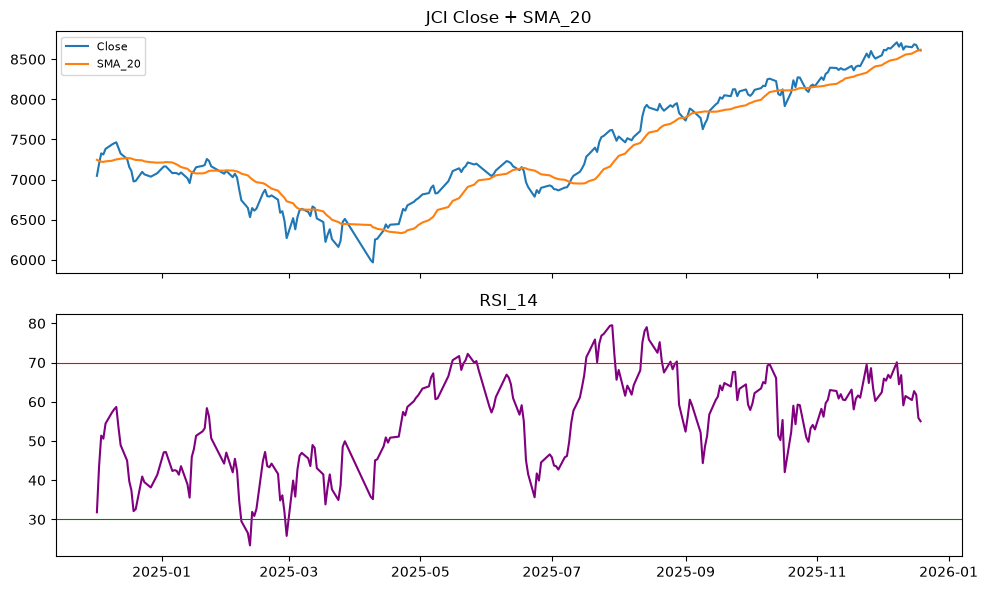

In [5]:
tail = df.tail(250)
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax.plot(tail["Date"], tail["Close"], label="Close")
ax.plot(tail["Date"], tail["SMA_20"], label="SMA_20")
ax.legend(fontsize=8)
ax.set_title("JCI Close + SMA_20")
ax2.plot(tail["Date"], tail["RSI_14"], color="purple")
ax2.axhline(70, color="red", linewidth=0.8)
ax2.axhline(30, color="green", linewidth=0.8)
ax2.set_title("RSI_14")
plt.tight_layout()
plt.show()

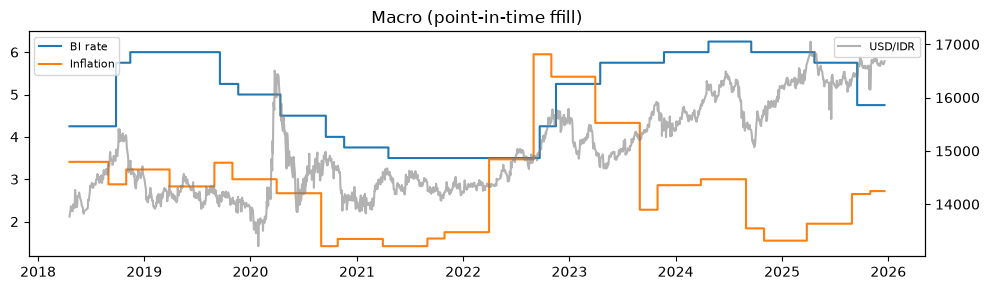

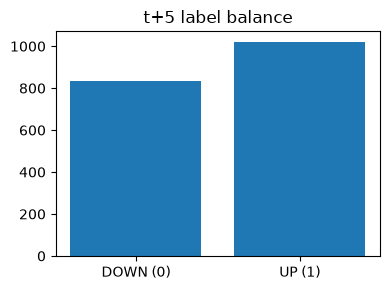

tensor shapes: (1825, 28, 7) (1825, 3) (1825, 64)


In [6]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.step(df["Date"], df["bi_rate"], label="BI rate")
ax.step(df["Date"], df["inflation_rate"], label="Inflation")
ax.legend(fontsize=8, loc="upper left")
ax.set_title("Macro (point-in-time ffill)")
ax2 = ax.twinx()
ax2.plot(df["Date"], df["usd_idr"], color="gray", alpha=0.6, label="USD/IDR")
ax2.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

counts = df["target_direction"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["DOWN (0)", "UP (1)"], [counts.get(0.0, 0), counts.get(1.0, 0)])
ax.set_title(f"t+{CFG.horizon} label balance")
plt.tight_layout()
plt.show()
X_tech, X_macro, X_news, y, dates, feat_scaler = make_tensors(df, train_end_df)
print("tensor shapes:", X_tech.shape, X_macro.shape, X_news.shape)

## Checks

Shapes, finiteness, binary labels, and proof the scalers saw the train prefix only.

In [7]:
assert X_tech.shape[1:] == (lb, len(CFG.tech_cols))
assert len(y) == n_win
assert np.isfinite(X_tech).all() and np.isfinite(X_macro).all()
assert set(np.unique(y)) <= {0.0, 1.0}
raw_tech = df[list(CFG.tech_cols)].values.astype(np.float32)
assert np.allclose(feat_scaler.data_min_, raw_tech[:train_end_df].min(axis=0))

# Thesis model checks
if _HAS_TORCH and model is not None:
    assert hasattr(model, "lstm") and hasattr(model, "mlp") and hasattr(model, "news_proj") and hasattr(model, "gate")
    assert model.lstm.hidden_size == CFG.lstm_dim
    assert model.mlp[-2].out_features == 16
    assert model.news_proj.out_features == CFG.lstm_dim
    assert model.gate.out_features == CFG.fusion_output_dim
    assert CFG.fusion_input_dim == CFG.lstm_dim + 16 + CFG.lstm_dim
    if metrics and "prob" in metrics:
        assert "prob" in metrics and "auc" in metrics
        assert "auc" in wf_metrics and "acc" in wf_metrics and "f1" in wf_metrics
    print("OK: thesis model architecture verified")

print("OK: leak-free single-notebook run passed")

OK: thesis model architecture verified
OK: leak-free single-notebook run passed
